In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_hr_limpio = pd.read_csv("../df_hr_limpio.csv")
df_hr_limpio.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Rarely,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4.0,Single,5993.0,8,Yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49,No,Frequently,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2.0,Married,5130.0,1,No,23,4,4,1,10,3.0,3,10,7,1,7.0


Visualización de datos de la empresa (general):

In [24]:
summary_data = {
    'Métrica': [
        'Total de Empleados',
        'Empleados Retenidos',
        'Empleados que se fueron',
        'Tasa de Rotación (%)',
        'Edad Promedio',
        'Salario Mensual Promedio',
        'Años en la Empresa (Promedio)',
        'Satisfacción Laboral Promedio',
        'Satisfacción en Entorno Promedio',
        'Equilibrio Trabajo-Vida Promedio'
    ],
    'Valor': [
        f"{len(df_hr_limpio):,}",
        f"{df_hr_limpio['attrition'].value_counts()['No']:,}",
        f"{df_hr_limpio['attrition'].value_counts()['Yes']:,}",
        f"{(df_hr_limpio['attrition'].value_counts()['Yes'] / len(df_hr_limpio) * 100):.1f}%",
        f"{df_hr_limpio['age'].mean():.1f} años",
        f"${df_hr_limpio['monthly_income'].mean():,.0f}",
        f"{df_hr_limpio['years_at_company'].mean():.1f} años",
        f"{df_hr_limpio['job_satisfaction'].mean():.2f} / 4.0",
        f"{df_hr_limpio['environment_satisfaction'].mean():.2f} / 4.0",
        f"{df_hr_limpio['work_life_balance'].mean():.2f} / 4.0"
    ]
}

summary_data_df = pd.DataFrame(summary_data)

summary_data_df

,Métrica,Valor
0,Total de Empleados,"1,470"
1,Empleados Retenidos,"1,233"
2,Empleados que se fueron,237
3,Tasa de Rotación (%),16.1%
4,Edad Promedio,36.9 años
5,Salario Mensual Promedio,"$6,484"
6,Años en la Empresa (Promedio),7.0 años
7,Satisfacción Laboral Promedio,2.74 / 4.0
8,Satisfacción en Entorno Promedio,2.72 / 4.0
9,Equilibrio Trabajo-Vida Promedio,2.76 / 4.0


C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\3385959517.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_hr_limpio, x='attrition', ax=axes[0], palette='viridis')


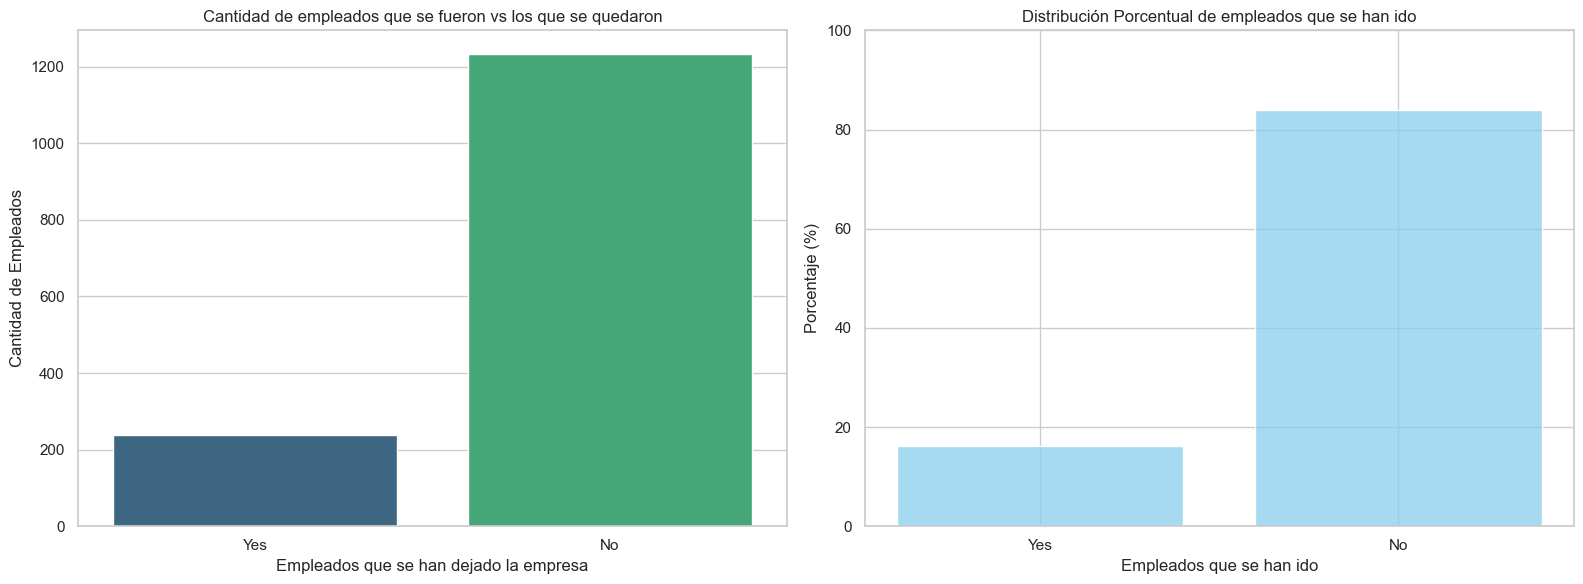

In [ ]:
# Attrition

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# --- GRÁFICO 1: Conteo Absoluto 
sns.countplot(data=df_hr_limpio, x='attrition', ax=axes[0], palette='viridis')
axes[0].set_title('Cantidad de empleados que se fueron vs los que se quedaron')
axes[0].set_xlabel('Empleados que se han dejado la empresa')
axes[0].set_ylabel('Cantidad de Empleados')

# --- GRÁFICO 2: Distribución Porcentual (Sugerido) ---
sns.histplot(data=df_hr_limpio, x='attrition', stat='percent', shrink=0.8, ax=axes[1], color='skyblue')
axes[1].set_title('Distribución Porcentual de empleados que se han ido')
axes[1].set_xlabel('Empleados que se han ido')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100) # Referencia visual completa

# Ajustar el espacio entre los gráficos para que no se encimen las etiquetas
plt.tight_layout()
plt.show()

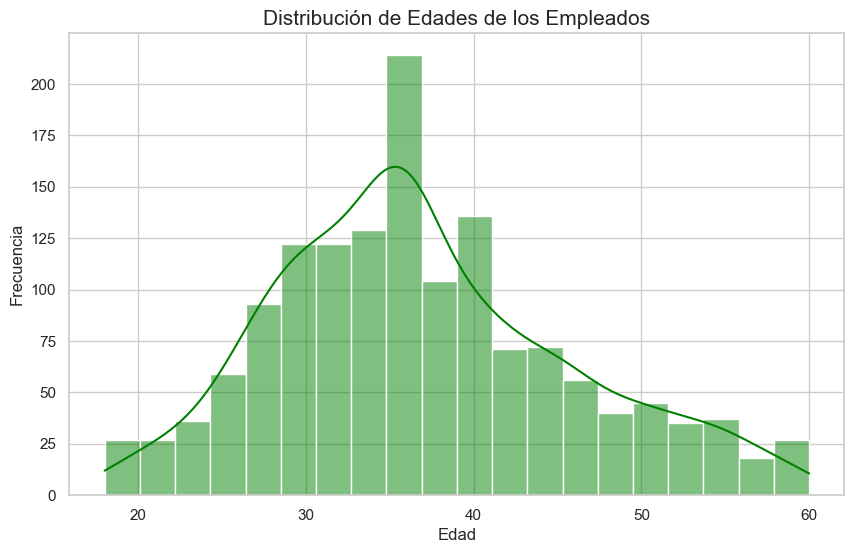

In [ ]:
# La distribución de edades con un histograma
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_hr_limpio['age'], kde=True, color='green', bins=20)
plt.title('Distribución de Edades de los Empleados', fontsize=15)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

In [ ]:
# Si dividimos a los empleados en "bloques" generacionales, vemos claramente dónde está el grueso de la plantilla:

# Jóvenes (18-25): 105 empleados. Es la base de entrada, pero no la más numerosa.

# Pico de Carrera (26-35): 575 empleados. Aquí está el "motor" de la empresa; es el grupo más grande.

# Consolidados (36-45): 524 empleados. Muy cerca del grupo anterior, lo que indica una plantilla con experiencia.

# Seniors (46-55): 213 empleados.

# Veteranos (56-60): 45 empleados. El grupo más reducido, acercándose a la edad de jubilación.

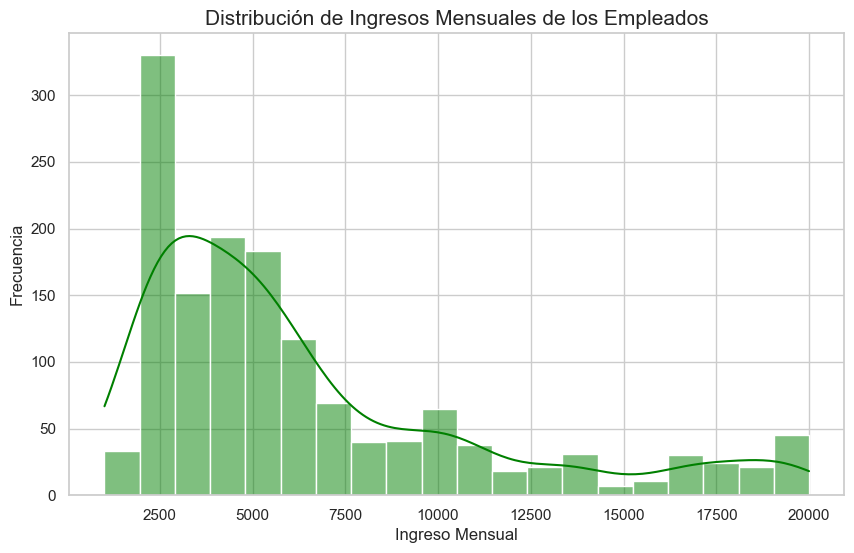

In [ ]:
# La distribución de salario con un histograma
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_hr_limpio['monthly_income'], kde=True, color='green', bins=20)
plt.title('Distribución de Ingresos Mensuales de los Empleados', fontsize=15)
plt.xlabel('Ingreso Mensual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

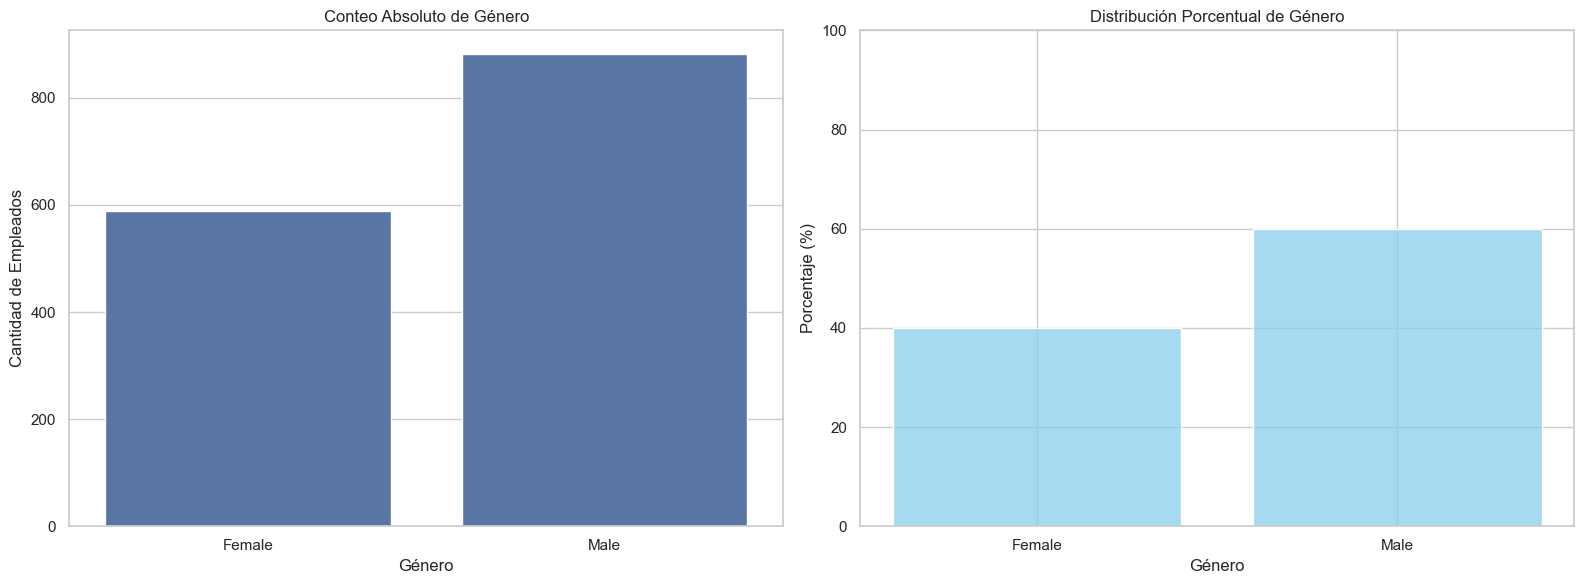

In [14]:
# La distribución genero absoluta y relativa

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Conteo Absoluto 
sns.countplot(data=df_hr_limpio, x='gender', ax=axes[0])
axes[0].set_title('Conteo Absoluto de Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de Empleados')

# --- GRÁFICO 2: Distribución Porcentual 
sns.histplot(data=df_hr_limpio, x='gender', stat='percent', shrink=0.8, ax=axes[1], color='skyblue')
axes[1].set_title('Distribución Porcentual de Género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100) # Referencia visual completa

# Ajustar el espacio entre los gráficos para que no se encimen las etiquetas
plt.tight_layout()
plt.show()

C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\1298320037.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_hr_limpio,
C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\1298320037.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_hr_limpio,


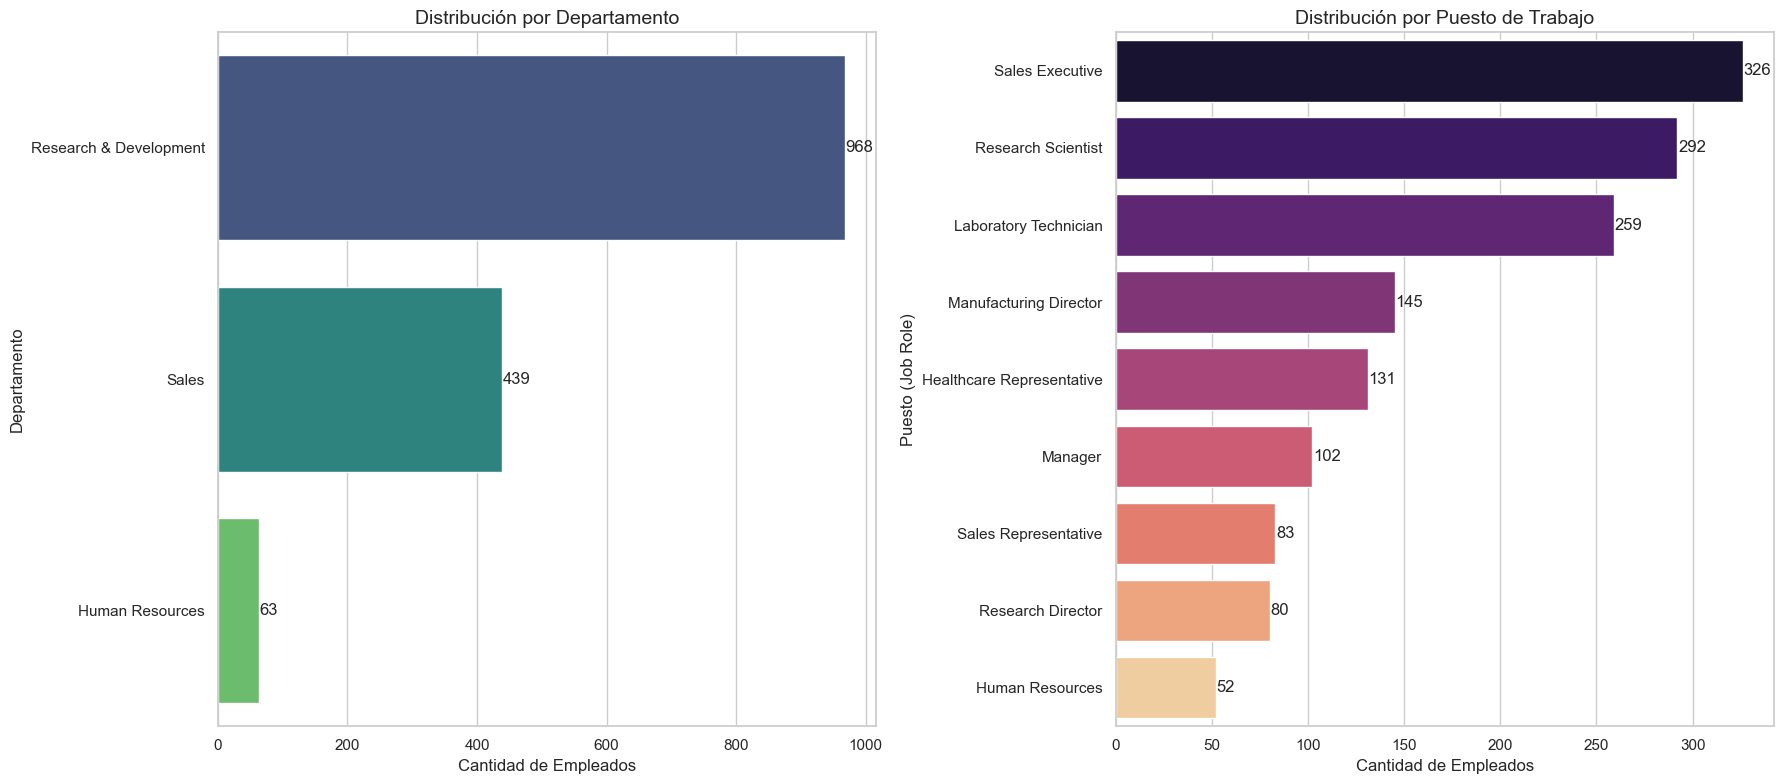

In [27]:
# Cuantos empleados por job role y por departamento dentro de la empresa:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos (Conteo ordenado)
order_dept = df_hr_limpio['department'].value_counts().index
order_role = df_hr_limpio['job_role'].value_counts().index

# 2. Configurar la figura con 2 subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- GRÁFICO 1: Empleados por Departamento ---
sns.countplot(data=df_hr_limpio, 
              y='department', 
              ax=axes[0], 
              order=order_dept, 
              palette='viridis')
axes[0].set_title('Distribución por Departamento', fontsize=14)
axes[0].set_xlabel('Cantidad de Empleados')
axes[0].set_ylabel('Departamento')

# Añadir etiquetas de valor en las barras de departamentos
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}', 
                     (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                     va='center')

# --- GRÁFICO 2: Empleados por Puesto (Job Role) ---
sns.countplot(data=df_hr_limpio, 
              y='job_role', 
              ax=axes[1], 
              order=order_role, 
              palette='magma')
axes[1].set_title('Distribución por Puesto de Trabajo', fontsize=14)
axes[1].set_xlabel('Cantidad de Empleados')
axes[1].set_ylabel('Puesto (Job Role)')

# Añadir etiquetas de valor en las barras de puestos
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', 
                     (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                     va='center')

# 3. Ajustar diseño final
plt.tight_layout()
plt.show()

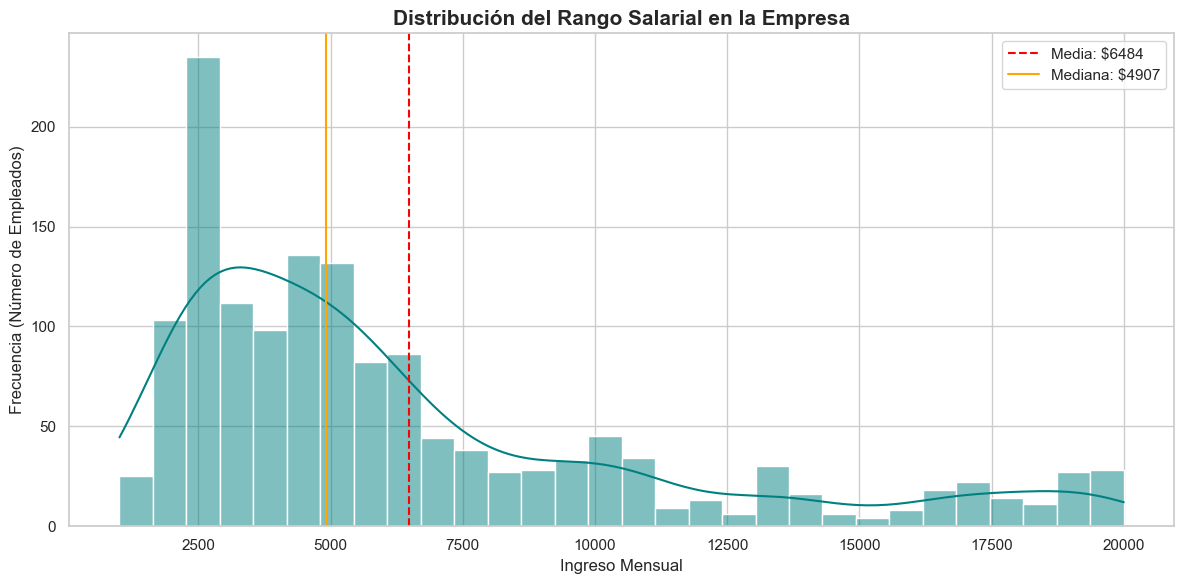

In [41]:
# Rango salarial


# Configuración de estilo
plt.figure(figsize=(12, 6))

# Crear el histograma con curva de densidad (KDE)
sns.histplot(data=df_hr_limpio, x='monthly_income', kde=True, color='teal', bins=30)

# Añadir líneas de referencia estadística
mean_income = df_hr_limpio['monthly_income'].mean()
median_income = df_hr_limpio['monthly_income'].median()

plt.axvline(mean_income, color='red', linestyle='--', label=f'Media: ${mean_income:.0f}')
plt.axvline(median_income, color='orange', linestyle='-', label=f'Mediana: ${median_income:.0f}')

# Estética y etiquetas
plt.title('Distribución del Rango Salarial en la Empresa', fontsize=15, fontweight='bold')
plt.xlabel('Ingreso Mensual', fontsize=12)
plt.ylabel('Frecuencia (Número de Empleados)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

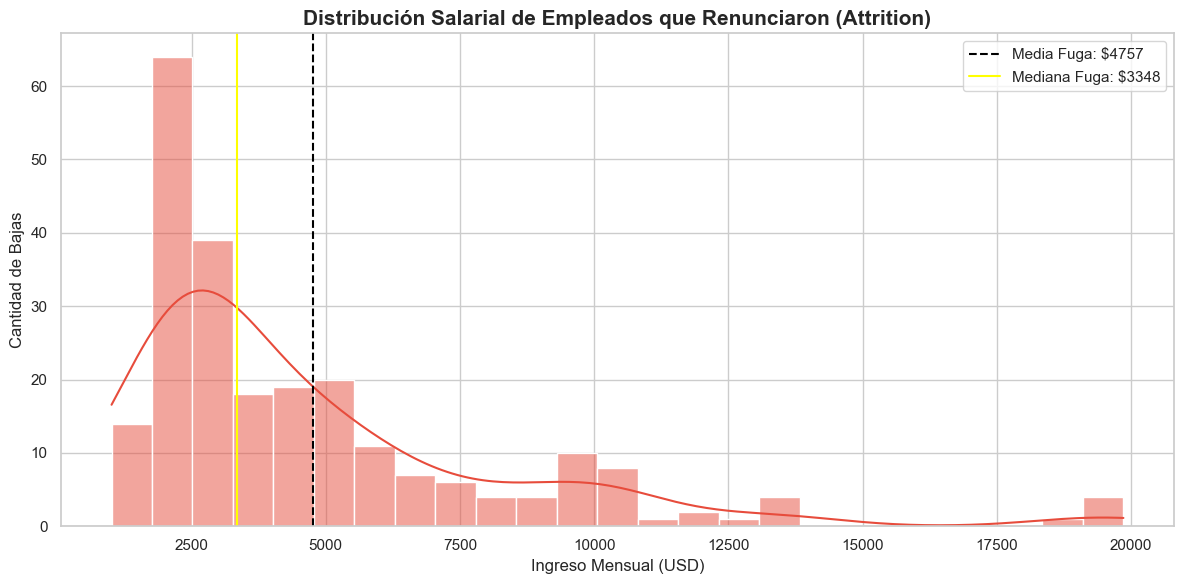

In [42]:
# Rango salarial solo de empleados que se han ido

# 1. Filtrar solo los empleados que se han ido
df_fuga = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']

# 2. Configuración de estilo
plt.figure(figsize=(12, 6))

# 3. Crear el histograma con curva de densidad
sns.histplot(data=df_fuga, x='monthly_income', kde=True, color='#e74c3c', bins=25)

# 4. Referencias estadísticas de la fuga
mean_fuga = df_fuga['monthly_income'].mean()
median_fuga = df_fuga['monthly_income'].median()

plt.axvline(mean_fuga, color='black', linestyle='--', label=f'Media Fuga: ${mean_fuga:.0f}')
plt.axvline(median_fuga, color='yellow', linestyle='-', label=f'Mediana Fuga: ${median_fuga:.0f}')

# 5. Estética
plt.title('Distribución Salarial de Empleados que Renunciaron (Attrition)', fontsize=15, fontweight='bold')
plt.xlabel('Ingreso Mensual (USD)', fontsize=12)
plt.ylabel('Cantidad de Bajas', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [117]:
df_hr_limpio.sample(5)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
57,35,No,Rarely,Research & Development,23,4,Medical,75,3,Female,30,3,1,Laboratory Technician,1.0,Married,4014.0,3,Yes,15,3,3,1,4,3.0,3,2,2,2,4.068783
716,41,No,Frequently,Research & Development,9,3,Medical,999,1,Male,64,3,5,Research Director,3.0,Divorced,19419.0,2,No,17,3,2,1,21,3.0,4,18,16,0,11.000000
1409,40,No,Frequently,Research & Development,11,3,Technical Degree,1985,4,Female,73,3,2,Laboratory Technician,3.0,Married,6323.0,1,No,11,3,1,1,10,2.0,4,10,9,9,4.000000
768,40,No,Rarely,Sales,26,3,Marketing,1066,3,Male,74,3,2,Sales Executive,1.0,Married,8396.0,1,No,14,3,2,1,8,3.0,2,7,7,7,5.000000
682,32,No,Non_Travel,Research & Development,1,3,Life Sciences,951,3,Female,70,2,1,Laboratory Technician,2.0,Married,2332.0,6,No,20,4,3,0,5,3.0,3,3,0,0,2.000000


Identificación de valores atípicos en las variables..

In [106]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return outliers

### Identificación de valores atípicos en cada variable numérica:

In [107]:
# Ejemplo con Salario (monthly_income):
outliers_salario = detectar_outliers(df_hr_limpio, 'monthly_income')
print(f"Número de outliers detectados en Salario: {len(outliers_salario)}")

Número de outliers detectados en Salario: 120


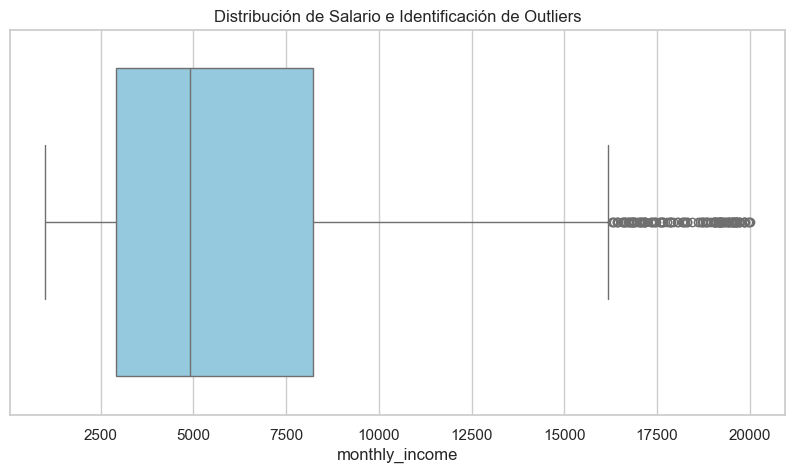

In [108]:
# Visualización de Outliers con Boxplot:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_hr_limpio['monthly_income'], color='skyblue')
plt.title('Distribución de Salario e Identificación de Outliers')
plt.show();

In [3]:
numericas = df_hr_limpio.select_dtypes(include=['number']).columns

numericas

Index(['age', 'distance_from_home', 'education', 'employee_number',
       'environment_satisfaction', 'hourly_rate', 'job_involvement',
       'job_level', 'job_satisfaction', 'monthly_income',
       'num_companies_worked', 'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')

Análisis de correlación entre variables numéricas

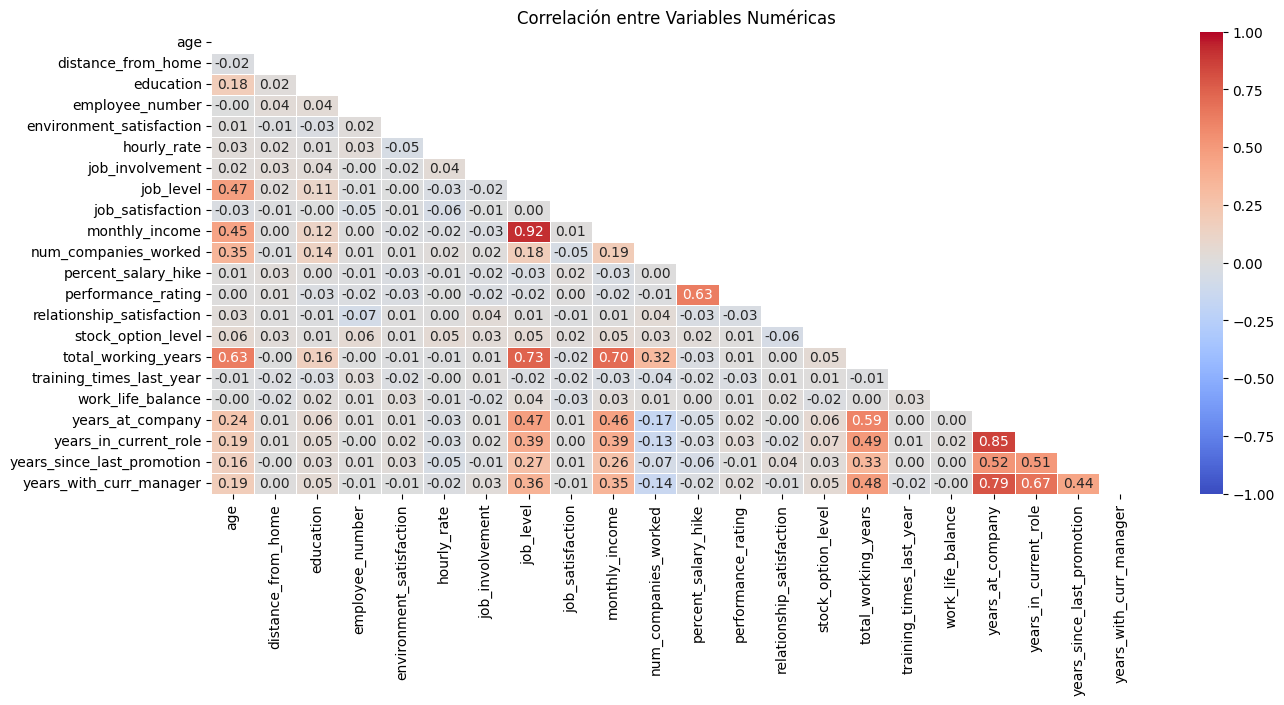

In [ ]:
# Calculamos la matriz de correlación de Spearman 

corr_matrix = df_hr_limpio[numericas].corr(method='spearman')

mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,vmin=-1, vmax=1, mask=mascara)
plt.title('Correlación entre Variables Numéricas')
plt.show()

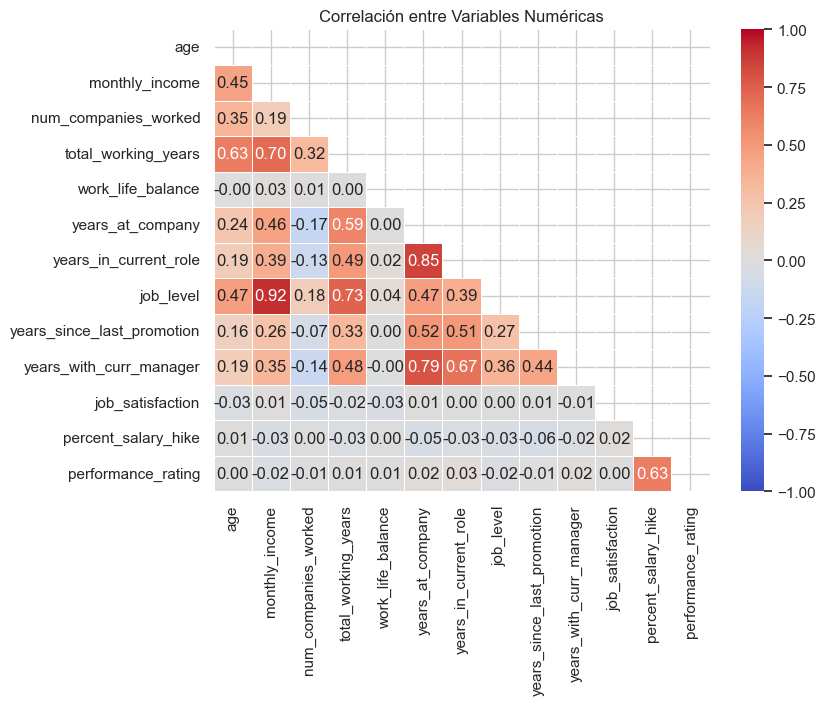

In [44]:
# Calculamos la matriz de correlación de Spearman 
from matplotlib.pylab import matrix

cols_interes = ['age', 'monthly_income', 'num_companies_worked', 'total_working_years','work_life_balance', 'years_at_company', 
                'years_in_current_role', 'job_level','years_since_last_promotion','years_with_curr_manager','job_satisfaction','percent_salary_hike', 'performance_rating']
corr_matrix = df_hr_limpio[cols_interes].corr(method='spearman')

mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,vmin=-1, vmax=1, mask=mascara)
plt.title('Correlación entre Variables Numéricas')
plt.show()

El heatmap revela cómo interactúan las diferentes variables de la plantilla:
1. 🚀 Las Correlaciones más Fuertes (Relación Directa)

Estas variables se mueven prácticamente juntas. Si una sube, la otra también:

    Sueldo y Nivel Jerárquico (0.92): Es la correlación más alta. El monthly_income está ligado casi exclusivamente al job_level. Esto indica una estructura salarial muy rígida y predecible basada en el rango.

    Antigüedad y Desempeño del Rol (0.85): years_at_company está fuertemente ligado a years_in_current_role y years_with_curr_manager. Esto sugiere que los empleados tienden a quedarse en el mismo equipo y con el mismo jefe durante mucho tiempo.

    Productividad y Aumento Salarial (0.63): Hay una conexión clara entre performance_rating y percent_salary_hike. Los aumentos de sueldo en esta empresa sí parecen estar basados en el rendimiento.

2. 📅 Evolución de Carrera y Edad

    Experiencia acumulada (0.73): El total_working_years es el mejor predictor del job_level. La empresa valora la trayectoria total (experiencia previa + actual) para asignar niveles de responsabilidad.

    Edad y Madurez (0.63): Como es lógico, a mayor age, mayor total_working_years, pero la relación no es perfecta (1.0), lo que indica que hay contrataciones de gente joven con mucha experiencia o perfiles senior que empezaron tarde en el sector.

3. 📉 Los "Puntos Ciegos" (Sin Correlación)

Estas son las sorpresas. Variables que no tienen nada que ver entre sí, aunque podrías pensar que sí:

    Satisfacción vs. Sueldo (~0.00): No hay correlación entre job_satisfaction y monthly_income. Esto es crítico: subir el sueldo no garantiza que el empleado esté más satisfecho con su trabajo en esta empresa.

    Distancia al hogar: La distance_from_home no parece afectar al rendimiento (performance_rating) ni a los años que alguien se queda en la empresa. El talento no depende de qué tan lejos vivan.

    Entorno y Jefe: Curiosamente, la satisfacción con el entorno (environment_satisfaction) no depende de cuántos años lleves con el mismo jefe.

💡 Conclusiones Estratégicas para HR:

    Retención Basada en Relaciones: Dado que los años en la empresa están muy ligados a los años con el mismo manager (0.72), la fuga de un jefe de equipo podría provocar una salida masiva de sus subordinados (efecto dominó).

    Fidelización No Económica: Como la satisfacción laboral no correlaciona con el salario, HR debería enfocarse en salario emocional, cultura o flexibilidad, ya que el dinero no está moviendo la aguja de la felicidad de los empleados.

    Promociones Estancadas: La correlación entre years_at_company y years_since_last_promotion (0.62) es alta. Esto confirma que hay un grupo de veteranos que "se queda atrás" en ascensos, lo que podría generar desmotivación a largo plazo.

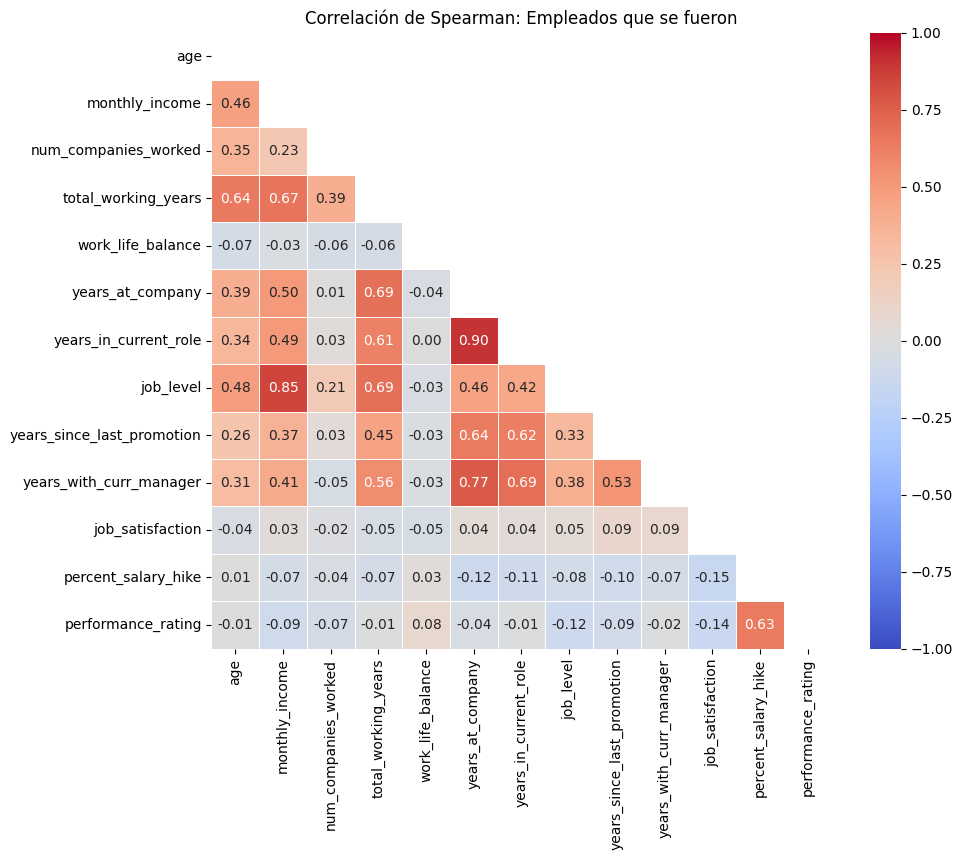

In [10]:
# 1. Filtramos el DataFrame para obtener solo los casos de Attrition = Yes
df_attrition_yes = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']

# 2. Definimos las columnas de interés
cols_interes

# 3. Calculamos la matriz de correlación de Spearman sobre el DataFrame filtrado
corr_matrix = df_attrition_yes[cols_interes].corr(method='spearman')

# 4. Configuramos la máscara para ocultar el triángulo superior
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,vmin=-1, vmax=1, mask=mascara)
plt.title('Correlación de Spearman: Empleados que se fueron')
plt.show();

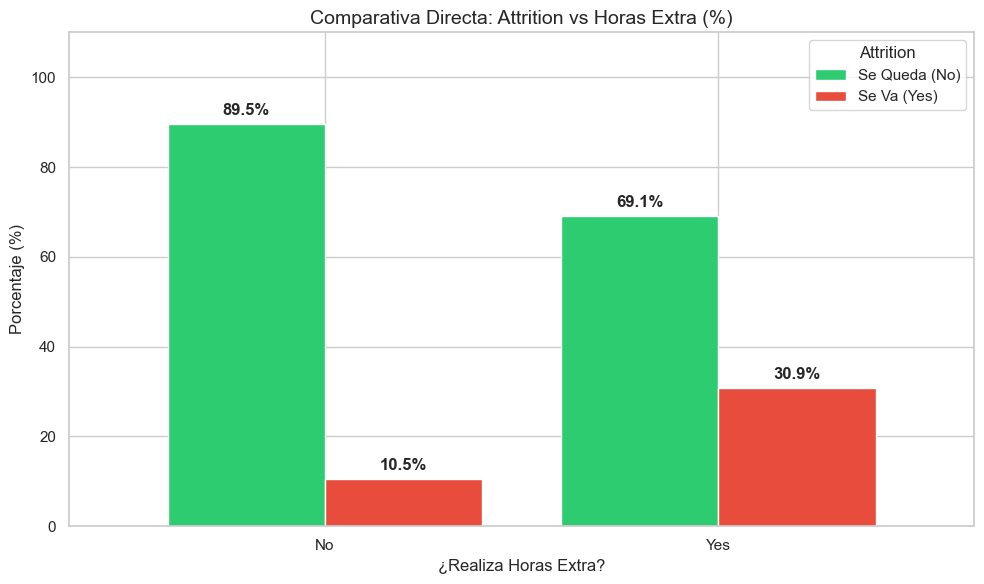

In [ ]:
#OVERTIME + ATTRITION


# 1. Crear tabla de contingencia normalizada
overtime_attrition_pct = pd.crosstab(df_hr_limpio['over_time'], 
                                    df_hr_limpio['attrition'], 
                                    normalize='index') * 100

# 2. Visualización con barras a la par (Grouped Bar Chart)
# El secreto es quitar 'stacked=True' (por defecto es False)
ax = overtime_attrition_pct.plot(kind='bar', 
                                 figsize=(10, 6), 
                                 color=['#2ecc71', '#e74c3c'],
                                 width=0.8)

plt.title('Comparativa Directa: Attrition vs Horas Extra (%)', fontsize=14)
plt.xlabel('¿Realiza Horas Extra?', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Attrition', labels=['Se Queda (No)', 'Se Va (Yes)'])
plt.xticks(rotation=0)
plt.ylim(0, 110) # Espacio extra para las etiquetas superiores

# 3. Añadir etiquetas de porcentaje sobre cada barra
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy() 
    ax.annotate(f'{height:.1f}%', (x + width/2, y + height + 2), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Datos:
attrition                No        Yes
job_satisfaction                      
1.0               77.385159  22.614841
2.0               83.272727  16.727273
3.0               83.369803  16.630197
4.0               88.791209  11.208791


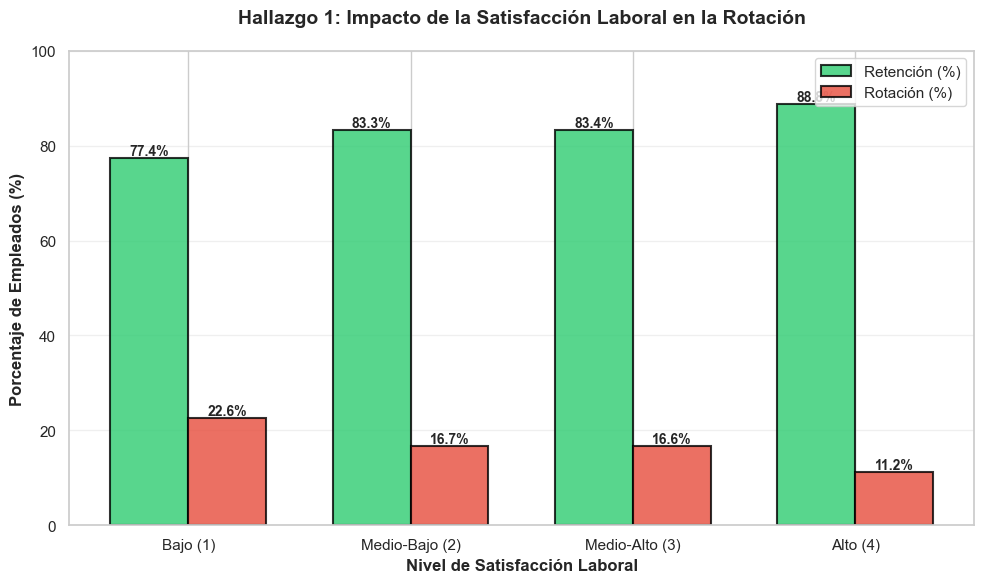

In [36]:
# SATISFACCION LABORAL + ATTRITION

# Código
satisfaction_attrition = pd.crosstab(
    df_hr_limpio['job_satisfaction'], 
    df_hr_limpio['attrition'], 
    normalize='index'
) * 100

print("\nDatos:")
print(satisfaction_attrition)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Bajo (1)', 'Medio-Bajo (2)', 'Medio-Alto (3)', 'Alto (4)']
retention = satisfaction_attrition['No'].values
rotation = satisfaction_attrition['Yes'].values

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, retention, width, label='Retención (%)', 
               color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x + width/2, rotation, width, label='Rotación (%)', 
               color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.8)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Nivel de Satisfacción Laboral', fontweight='bold', fontsize=12)
ax.set_ylabel('Porcentaje de Empleados (%)', fontweight='bold', fontsize=12)
ax.set_title('Hallazgo 1: Impacto de la Satisfacción Laboral en la Rotación', 
             fontweight='bold', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

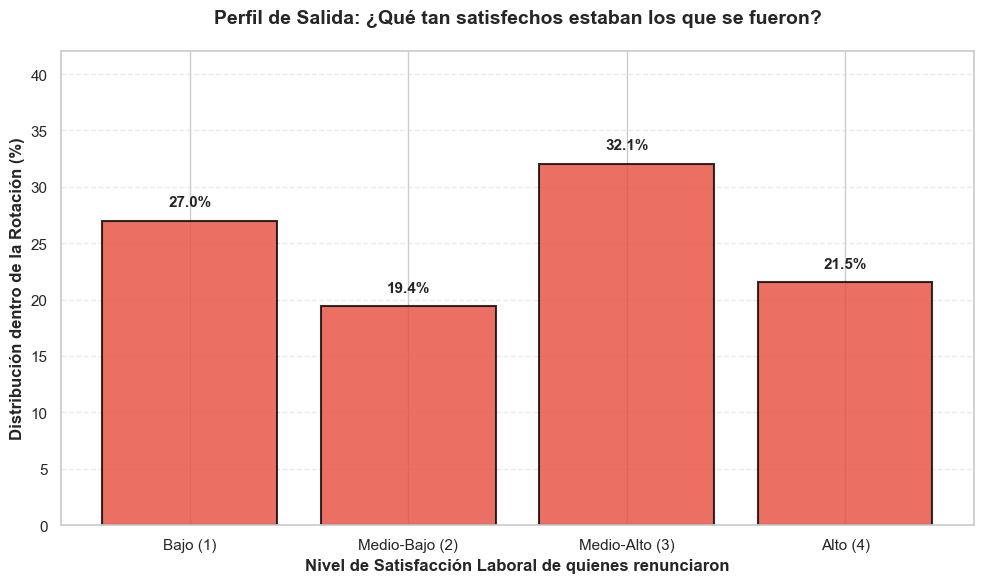

In [33]:
# Satisfaccion laboral solo de los empleados que se han ido

# 1. Calcular la tabla de contingencia (Normalizada por columna de salida para ver distribución interna)
# Queremos saber: De todos los que se fueron, ¿qué % tenía cada nivel de satisfacción?
fuga_total = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']
distribucion_fuga = fuga_total['job_satisfaction'].value_counts(normalize=True).sort_index() * 100

# 2. Configuración del Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Bajo (1)', 'Medio-Bajo (2)', 'Medio-Alto (3)', 'Alto (4)']
valores = distribucion_fuga.values

# Crear las barras
bars = ax.bar(categories, valores, color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.8)

# Añadir etiquetas de porcentaje sobre cada barra
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Estética y etiquetas
ax.set_xlabel('Nivel de Satisfacción Laboral de quienes renunciaron', fontweight='bold', fontsize=12)
ax.set_ylabel('Distribución dentro de la Rotación (%)', fontweight='bold', fontsize=12)
ax.set_title('Perfil de Salida: ¿Qué tan satisfechos estaban los que se fueron?', 
             fontweight='bold', fontsize=14, pad=20)

ax.set_ylim(0, max(valores) + 10) # Ajuste dinámico del techo del gráfico
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

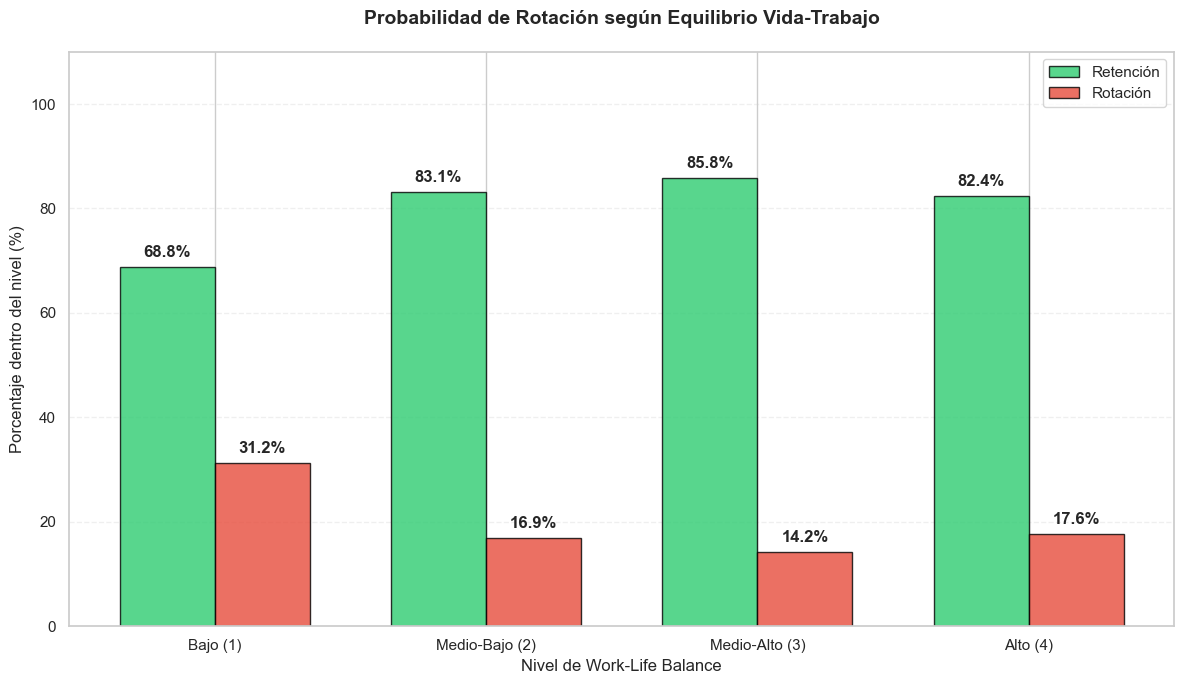

In [48]:
# Work_life_balance - Comparativa Retención vs. Rotación:


# 1. Preparación de la tabla de contingencia (Normalizada por FILA)
# Esto calcula: de cada nivel de WLB, qué % se queda y qué % se va.
wlb_attrition = pd.crosstab(
    df_hr_limpio['work_life_balance'], 
    df_hr_limpio['attrition'], 
    normalize='index'
) * 100

# 2. Configuración del Gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Definiciones para el eje X
labels = ['Bajo (1)', 'Medio-Bajo (2)', 'Medio-Alto (3)', 'Alto (4)']
x = np.arange(len(labels))
width = 0.35

# Creación de las barras
bars_retencion = ax.bar(x - width/2, wlb_attrition['No'], width, 
                        label='Retención', color='#2ecc71', edgecolor='black', alpha=0.8)
bars_rotacion = ax.bar(x + width/2, wlb_attrition['Yes'], width, 
                       label='Rotación', color='#e74c3c', edgecolor='black', alpha=0.8)

# 3. Añadir etiquetas de porcentaje sobre las barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # Desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

add_labels(bars_retencion)
add_labels(bars_rotacion)

# 4. Estética y limpieza
ax.set_title('Probabilidad de Rotación según Equilibrio Vida-Trabajo', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Porcentaje dentro del nivel (%)', fontsize=12)
ax.set_xlabel('Nivel de Work-Life Balance', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 110) # Espacio para las etiquetas
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Hallazgo_Equilibrio_Trabajo_Vida.png', dpi=300, bbox_inches='tight')
plt.show()

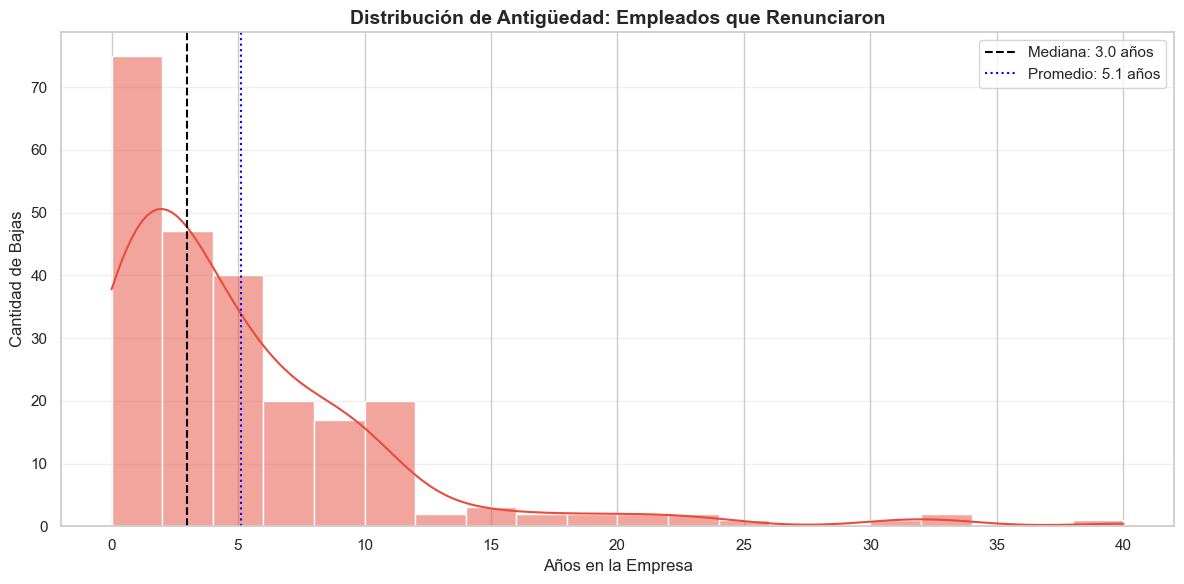

In [49]:
# Antiguedad de empleados que se han ido de la empresa

# 1. Filtrar solo empleados que se han ido
df_fuga = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']

# 2. Configuración del gráfico
plt.figure(figsize=(12, 6))

# 3. Crear el histograma con curva de densidad
sns.histplot(data=df_fuga, x='years_at_company', kde=True, color='#e74c3c', bins=20)

# 4. Estadísticas clave para el insight
mediana_antiguedad = df_fuga['years_at_company'].median()
promedio_antiguedad = df_fuga['years_at_company'].mean()

plt.axvline(mediana_antiguedad, color='black', linestyle='--', label=f'Mediana: {mediana_antiguedad:.1f} años')
plt.axvline(promedio_antiguedad, color='blue', linestyle=':', label=f'Promedio: {promedio_antiguedad:.1f} años')

# Estética
plt.title('Distribución de Antigüedad: Empleados que Renunciaron', fontsize=14, fontweight='bold')
plt.xlabel('Años en la Empresa', fontsize=12)
plt.ylabel('Cantidad de Bajas', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\3729850360.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_hr_limpio[df_hr_limpio['attrition'] == 'No'],
C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\3729850360.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_hr_limpio[df_hr_limpio['attrition'] == 'Yes'],


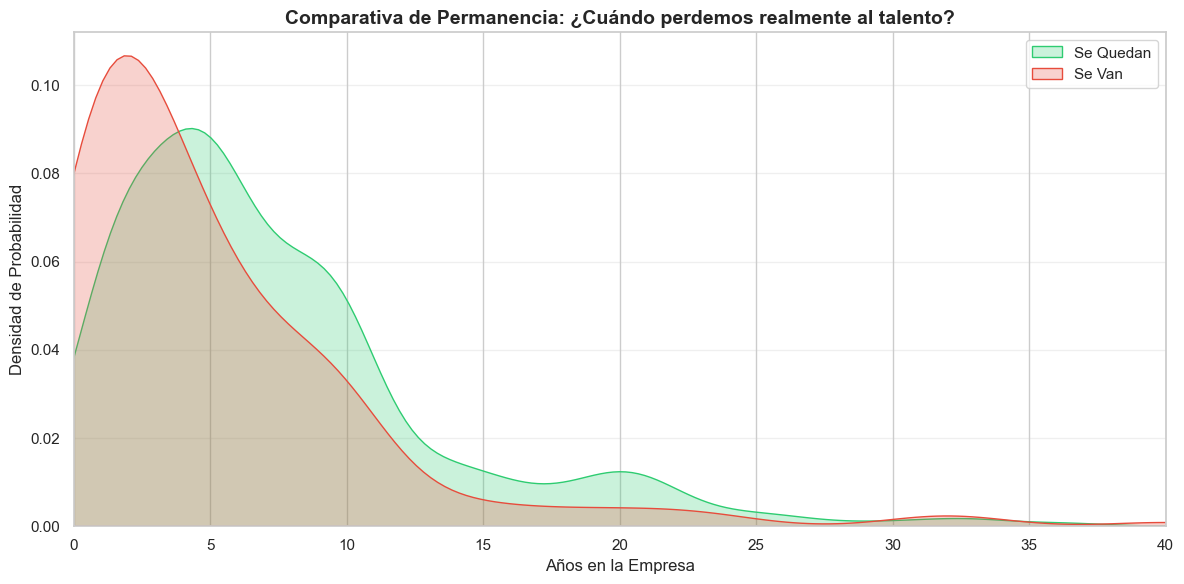

In [ ]:
# Comparacion de la antiguedad de los que se van con los que se quedan,  se usa la variable years_at_company porque total_working_years se refiere a la experiencia laboral

plt.figure(figsize=(12, 6))

# Graficamos ambas distribuciones
sns.kdeplot(data=df_hr_limpio[df_hr_limpio['attrition'] == 'No'], 
            x='years_at_company', label='Se Quedan', shade=True, color='#2ecc71')

sns.kdeplot(data=df_hr_limpio[df_hr_limpio['attrition'] == 'Yes'], 
            x='years_at_company', label='Se Van', shade=True, color='#e74c3c')

# Estética y límites
plt.title('Comparativa de Permanencia: ¿Cuándo perdemos realmente al talento?', fontsize=14, fontweight='bold')
plt.xlabel('Años en la Empresa', fontsize=12)
plt.ylabel('Densidad de Probabilidad')
plt.xlim(0, df_hr_limpio['years_at_company'].max())
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\4246868904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wlb4, x='attrition', y='years_since_last_promotion',


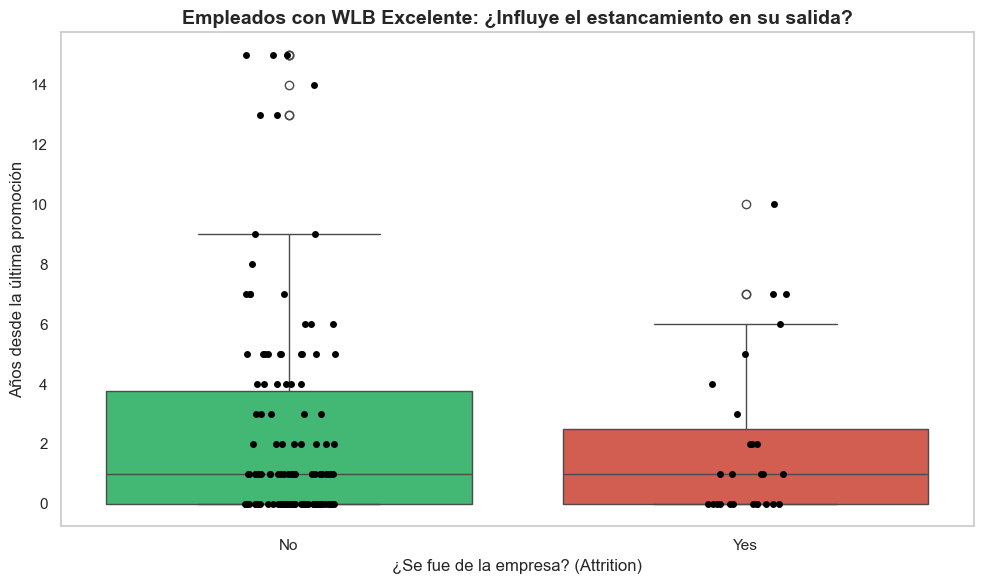

In [ ]:
# Calificacion 4 en work life balance vs years at company

# 1. Filtrar solo el grupo de interés: Work-Life Balance Excelente (4)
df_wlb4 = df_hr_limpio[df_hr_limpio['work_life_balance'] == 4]

# 2. Visualización: Boxplot con Stripplot para ver la distribución de promociones
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_wlb4, x='attrition', y='years_since_last_promotion', 
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})

sns.stripplot(data=df_wlb4, x='attrition', y='years_since_last_promotion', 
              color='black', jitter=True)

# 3. Estética
plt.title('Empleados con WLB Excelente: ¿Influye el estancamiento en su salida?', 
          fontsize=14, fontweight='bold')
plt.xlabel('¿Se fue de la empresa? (Attrition)', fontsize=12)
plt.ylabel('Años desde la última promoción', fontsize=12)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

C:\Users\rosas\AppData\Local\Temp\ipykernel_51244\2190879725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hr_limpio, x='job_level', y='monthly_income',


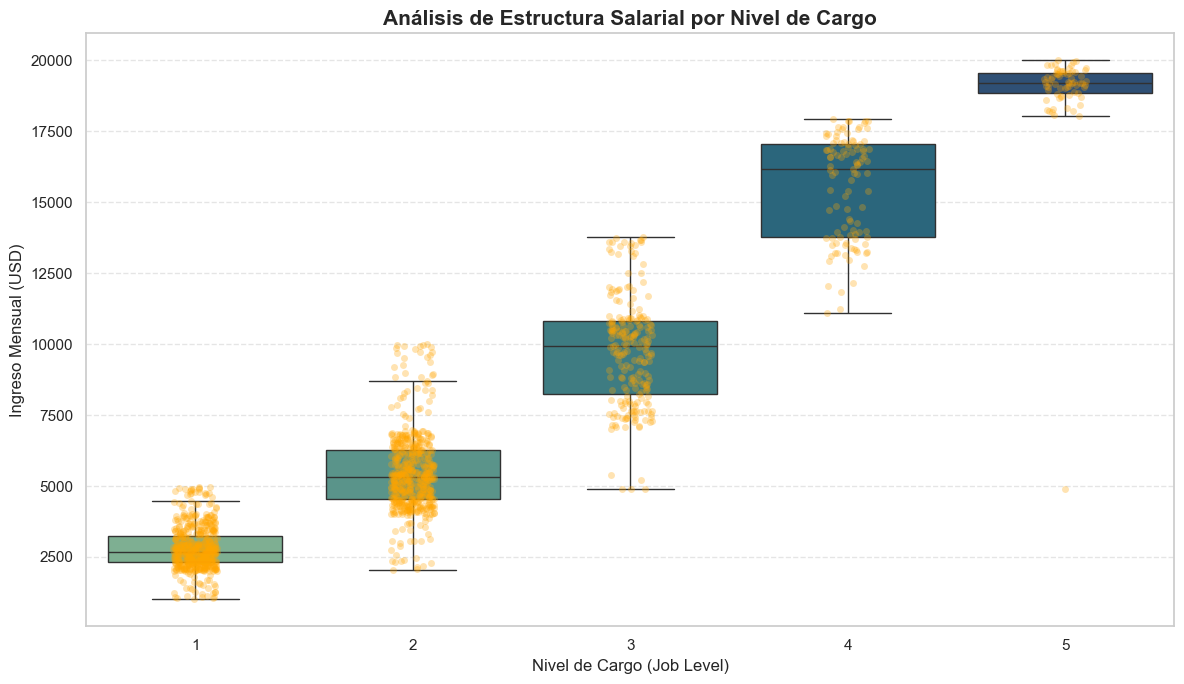

In [34]:
# JOB LEVEL VS MONTHLY INCOME


# 1. Configuración de la figura
plt.figure(figsize=(12, 7))

# 2. Crear el Boxplot (Muestra cuartiles y mediana)
sns.boxplot(data=df_hr_limpio, x='job_level', y='monthly_income', 
            palette='crest', fliersize=0)

# 3. Superponer un Stripplot (Muestra la densidad de empleados reales)
sns.stripplot(data=df_hr_limpio, x='job_level', y='monthly_income', 
              color='orange', alpha=0.3, jitter=True)

# 4. Estética y etiquetas
plt.title('Análisis de Estructura Salarial por Nivel de Cargo', fontsize=15, fontweight='bold')
plt.xlabel('Nivel de Cargo (Job Level)', fontsize=12)
plt.ylabel('Ingreso Mensual (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

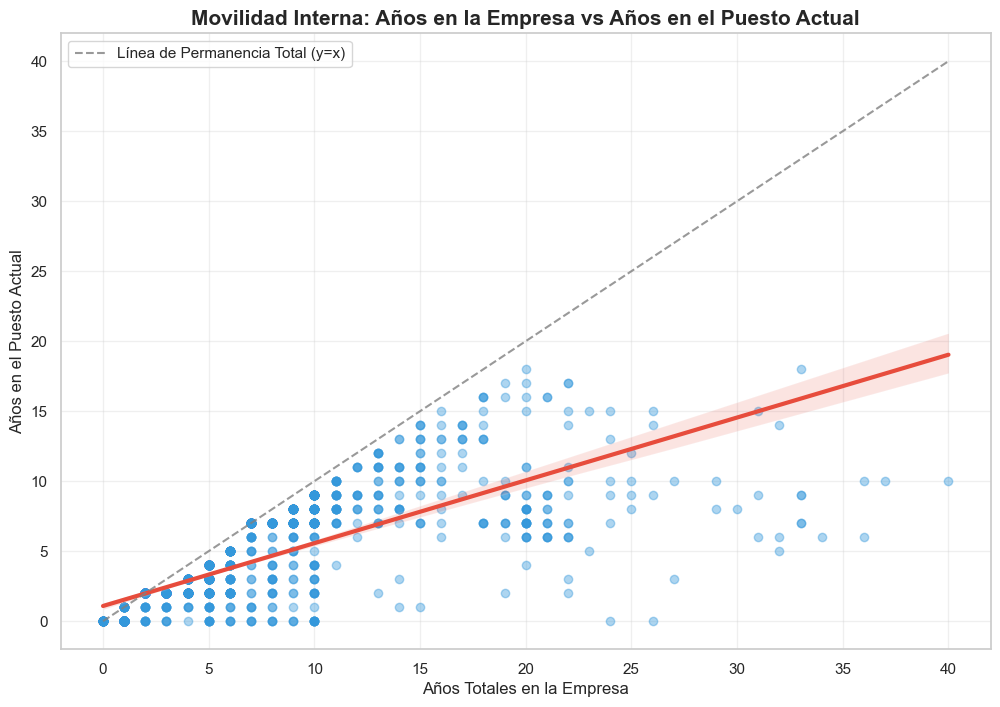

In [35]:
# Cuanto llevan los empleados en su mismo puesto de trabajo vs los años que llevan en la compañia?

plt.figure(figsize=(12, 8))

# Crear el gráfico de dispersión con línea de regresión
sns.regplot(data=df_hr_limpio, 
            x='years_at_company', 
            y='years_in_current_role',
            scatter_kws={'alpha':0.4, 'color':'#3498db'},
            line_kws={'color':'#e74c3c', 'lw':3})

# Añadir una línea de identidad (y=x) para referencia técnica
max_val = max(df_hr_limpio['years_at_company'].max(), df_hr_limpio['years_in_current_role'].max())
plt.plot([0, max_val], [0, max_val], '--', color='gray', alpha=0.8, label='Línea de Permanencia Total (y=x)')

plt.title('Movilidad Interna: Años en la Empresa vs Años en el Puesto Actual', fontsize=15, fontweight='bold')
plt.xlabel('Años Totales en la Empresa', fontsize=12)
plt.ylabel('Años en el Puesto Actual', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()